In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("listings.csv")

print("Initial Shape:", df.shape)
print(df.head())

Initial Shape: (45421, 79)
     id                        listing_url       scrape_id last_scraped  \
0  2708  https://www.airbnb.com/rooms/2708  20250617032927   2025-06-17   
1  2732  https://www.airbnb.com/rooms/2732  20250617032927   2025-06-17   
2  2864  https://www.airbnb.com/rooms/2864  20250617032927   2025-06-17   
3  6033  https://www.airbnb.com/rooms/6033  20250617032927   2025-06-17   
4  6931  https://www.airbnb.com/rooms/6931  20250617032927   2025-06-17   

            source                                               name  \
0      city scrape  Run Runyon, Beaut Furn Mirror Mini-Suit w/ Fir...   
1      city scrape                              Zen Life at the Beach   
2  previous scrape             * Beautiful Master Suite/Jacuzzi Tub/*   
3  previous scrape                           Poolside Serenity Studio   
4      city scrape  RUN Runyon, Beau Furn Rms Terrace Hollyw Hill ...   

                                         description  \
0  Run Runyon Canyon<br /><

In [3]:
df.describe()

,id,scrape_id,host_id,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,4.542100e+04,4.542100e+04,4.542100e+04,45414.000000,45414.000000,45421.000000,45421.000000,45421.000000,36588.000000,42358.000000,...,32841.000000,32833.000000,32839.000000,32832.000000,32831.000000,45421.000000,45421.000000,45421.000000,45421.000000,32849.000000
mean,6.490782e+17,2.025062e+13,2.137708e+08,120.426983,168.288722,34.055275,-118.309934,4.050461,1.653766,1.803673,...,4.748009,4.853984,4.854049,4.791058,4.706046,20.535897,16.280817,3.366306,0.192532,1.363129
std,5.694868e+17,2.910188e+00,2.107937e+08,670.154114,876.674501,0.144776,0.173013,2.877310,1.208846,1.317982,...,0.446472,0.382428,0.393493,0.396185,0.457817,71.836980,70.134005,13.692049,2.104227,1.748087
min,2.708000e+03,2.025062e+13,7.670000e+02,0.000000,0.000000,33.338540,-118.917134,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.010000
25%,3.714937e+07,2.025062e+13,2.848372e+07,1.000000,2.000000,33.998240,-118.411370,2.000000,1.000000,1.000000,...,4.690000,4.860000,4.870000,4.750000,4.650000,1.000000,1.000000,0.000000,0.000000,0.200000
50%,7.703370e+17,2.025062e+13,1.249258e+08,3.000000,5.000000,34.061650,-118.340640,3.000000,1.000000,1.000000,...,4.880000,4.970000,4.980000,4.910000,4.820000,2.000000,1.000000,0.000000,0.000000,0.700000
75%,1.199336e+18,2.025062e+13,4.042549e+08,13.000000,20.000000,34.108380,-118.224403,6.000000,2.000000,2.000000,...,5.000000,5.000000,5.000000,5.000000,4.970000,10.000000,6.000000,1.000000,0.000000,2.020000
max,1.444599e+18,2.025062e+13,7.015455e+08,4925.000000,9109.000000,34.811180,-117.654300,16.000000,32.500000,24.000000,...,5.000000,5.000000,5.070000,5.000000,5.000000,599.000000,599.000000,133.000000,38.000000,74.260000


In [4]:
drop_cols = [
'id','listing_url','scrape_id','last_scraped','source',
'picture_url','host_id','host_url','host_thumbnail_url','host_picture_url',
'calendar_last_scraped','calendar_updated','name','description',
'host_name','first_review','last_review','host_about','neighborhood_overview'
]

df.drop(columns=[col for col in drop_cols if col in df.columns], inplace=True)

In [5]:
df['price'] = df['price'].replace('[$,]', '', regex=True).astype(float)
df = df[df['price'] > 0]
df = df[df['price'] < df['price'].quantile(0.99)]

In [6]:
df = df[df['estimated_revenue_l365d'].notna()]
df['estimated_revenue_l365d'] = df['estimated_revenue_l365d'].astype(float)

In [7]:
for col in ['host_response_rate','host_acceptance_rate']:
  if col in df.columns:
    df[col] = df[col].str.rstrip('%').astype(float)/100

In [8]:
bool_cols = ['host_is_superhost','host_has_profile_pic','host_identity_verified',
'instant_bookable','has_availability']

for col in bool_cols:
  if col in df.columns:
    df[col] = df[col].map({'t':1,'f':0,'True':1,'False':0})

In [9]:
df.fillna(df.median(numeric_only=True), inplace=True)

cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna("missing")

In [10]:
df = df[df['number_of_reviews'] >= 0]

In [11]:
df['amenities_count'] = df['amenities'].apply(
lambda x: len(eval(x)) if pd.notnull(x) else 0
)
df['amenities_count'] = df['amenities_count'].astype(int)
df = df[df['amenities_count'] >= 0]

In [12]:
df['host_reliability'] = (
    df.get('host_response_rate',0) +
    df.get('host_acceptance_rate',0) +
    (df.get('review_scores_rating',0)/5) +
    df.get('host_is_superhost',0)
) / 4

In [13]:
df = df[df['estimated_revenue_l365d'] > 0]

df['rev_class'] = pd.qcut(
    df['estimated_revenue_l365d'], q=3, labels=["Low", "Mid", "High"]
)

In [14]:
df['rev_per_guest'] = df['estimated_revenue_l365d'] / (df['accommodates'] + 1)
df['rev_per_occ'] = df['estimated_revenue_l365d'] / (df['estimated_occupancy_l365d'] + 1)

In [15]:
print("\nRevenue by Class:")
print(df.groupby('rev_class')['estimated_revenue_l365d'].mean())


Revenue by Class:
rev_class
Low      4332.768159
Mid     16341.330069
High    54057.371601
Name: estimated_revenue_l365d, dtype: float64


/var/folders/f5/r_4n8c2j2qs88z3chgyzp6h00000gn/T/ipykernel_50813/213585731.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('rev_class')['estimated_revenue_l365d'].mean())


# VISUALIZATIONS

### At what price range does revenue peak? Is there an optimal price range?

In [16]:
price_bins = pd.cut(df['price'], bins=8)
price_analysis = df.groupby(price_bins)['estimated_revenue_l365d'].mean()
print(price_analysis)

price
(4.529, 315.875]        18219.375457
(315.875, 624.75]       45806.428781
(624.75, 933.625]       68718.787270
(933.625, 1242.5]       92846.166667
(1242.5, 1551.375]      99304.820144
(1551.375, 1860.25]    133742.520000
(1860.25, 2169.125]    163429.814815
(2169.125, 2478.0]     127706.541667
Name: estimated_revenue_l365d, dtype: float64


/var/folders/f5/r_4n8c2j2qs88z3chgyzp6h00000gn/T/ipykernel_50813/3382623416.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_analysis = df.groupby(price_bins)['estimated_revenue_l365d'].mean()


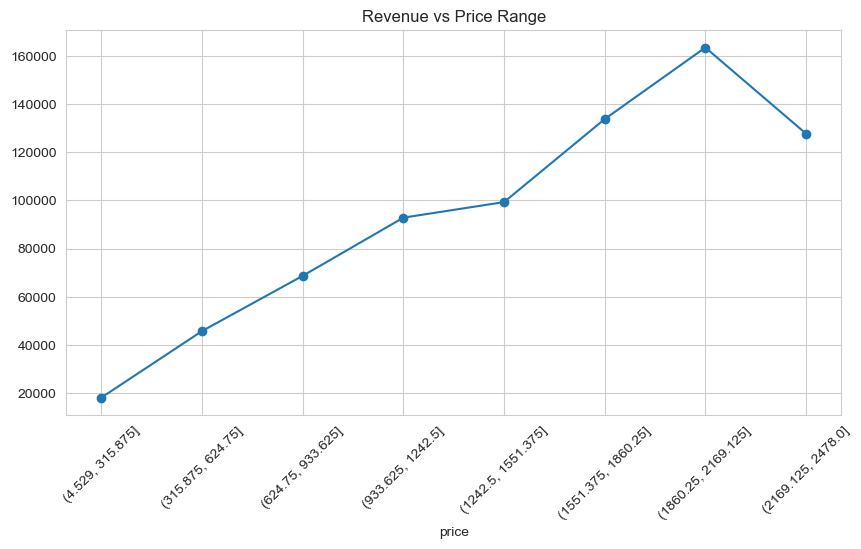

In [17]:
plt.figure(figsize=(10,5))
price_analysis.plot(marker='o')
plt.xticks(rotation=45)
plt.title("Revenue vs Price Range")
plt.show()

### Do more amenities always increase revenue?

In [18]:
bins = [0, 5, 10, 15, 20, 30, 50, 100]
labels = ["0-5","6-10","11-15","16-20","21-30","31-50","50+"]

amen_bins = pd.cut(
    df['amenities_count'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

amen_analysis = df.groupby(amen_bins)['estimated_revenue_l365d'].mean()
print(amen_analysis)

amenities_count
0-5       5870.226415
6-10      6797.300792
11-15     9384.877747
16-20    12889.285714
21-30    15131.525230
31-50    21222.316050
50+      37510.688432
Name: estimated_revenue_l365d, dtype: float64


/var/folders/f5/r_4n8c2j2qs88z3chgyzp6h00000gn/T/ipykernel_50813/2602675980.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  amen_analysis = df.groupby(amen_bins)['estimated_revenue_l365d'].mean()


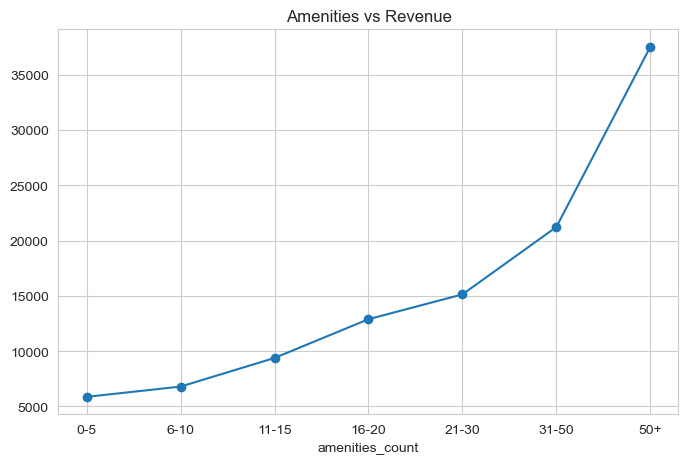

In [19]:
plt.figure(figsize=(8,5))
amen_analysis.plot(marker='o')
plt.title("Amenities vs Revenue")
plt.show()

### Does host reliability matter equally across different revenue classes?

In [20]:
host_reliability_mean = df.groupby('rev_class')['host_reliability'].mean()
print("\nHost Reliability by Class:")
print(host_reliability_mean)


Host Reliability by Class:
rev_class
Low     0.797583
Mid     0.864126
High    0.913089
Name: host_reliability, dtype: float64


/var/folders/f5/r_4n8c2j2qs88z3chgyzp6h00000gn/T/ipykernel_50813/4238419437.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  host_reliability_mean = df.groupby('rev_class')['host_reliability'].mean()


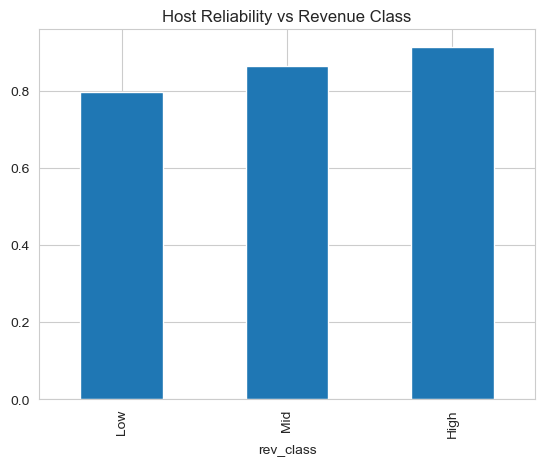

In [21]:
host_reliability_mean.plot(kind='bar')
plt.title("Host Reliability vs Revenue Class")
plt.show()

### Does increasing accommodation capacity always increase revenue per guest?

In [22]:
capacity_analysis = df.groupby('accommodates')['rev_per_guest'].mean()
print(capacity_analysis)

accommodates
1     3600.107330
2     5071.292068
3     4721.073174
4     4843.085219
5     4684.215284
6     4966.177918
7     4398.156847
8     4997.920667
9     4075.892929
10    5163.015679
11    2962.076840
12    3838.966555
13    3870.697802
14    3967.981572
15    4562.485000
16    4094.019258
Name: rev_per_guest, dtype: float64


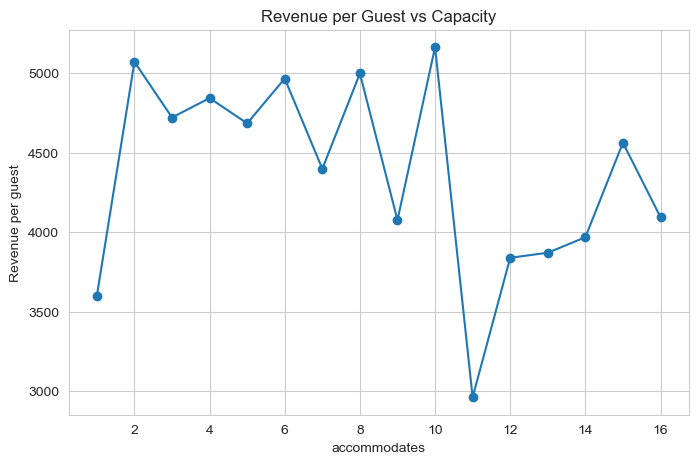

In [23]:
plt.figure(figsize=(8,5))
capacity_analysis.plot(marker='o')
plt.title("Revenue per Guest vs Capacity")
plt.ylabel("Revenue per guest")
plt.show()

### Do more reviews always imply higher revenue?

In [24]:
bins = [0, 10, 50, 100, 200, 500, 1000]
labels = ["0-10","11-50","51-100","101-200","201-500","500+"]

review_bins = pd.cut(
    df['number_of_reviews'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

review_analysis = df.groupby(review_bins)['estimated_revenue_l365d'].mean()
review_analysis


/var/folders/f5/r_4n8c2j2qs88z3chgyzp6h00000gn/T/ipykernel_50813/2624968806.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  review_analysis = df.groupby(review_bins)['estimated_revenue_l365d'].mean()


number_of_reviews
0-10       13158.333079
11-50      27564.828474
51-100     35130.250741
101-200    35915.145330
201-500    34305.994613
500+       32473.490291
Name: estimated_revenue_l365d, dtype: float64

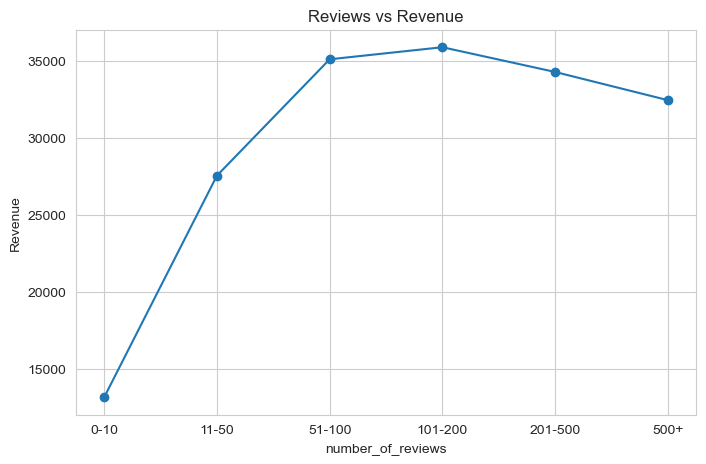

In [25]:
plt.figure(figsize=(8,5))
review_analysis.plot(marker='o')
plt.title("Reviews vs Revenue")
plt.ylabel("Revenue")
plt.show()

### Which room types contributes the most to each class?

In [26]:
price_by_room_rev_class = df.groupby(['rev_class','room_type'])['price'].mean().unstack()
print(price_by_room_rev_class)

room_type  Entire home/apt  Hotel room  Private room  Shared room
rev_class                                                        
Low             194.168345  273.479167     74.153616    38.717391
Mid             205.578423  353.117647     93.213455    56.000000
High            339.266837  352.875000    182.557940   437.333333


/var/folders/f5/r_4n8c2j2qs88z3chgyzp6h00000gn/T/ipykernel_50813/1537643038.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_by_room_rev_class = df.groupby(['rev_class','room_type'])['price'].mean().unstack()


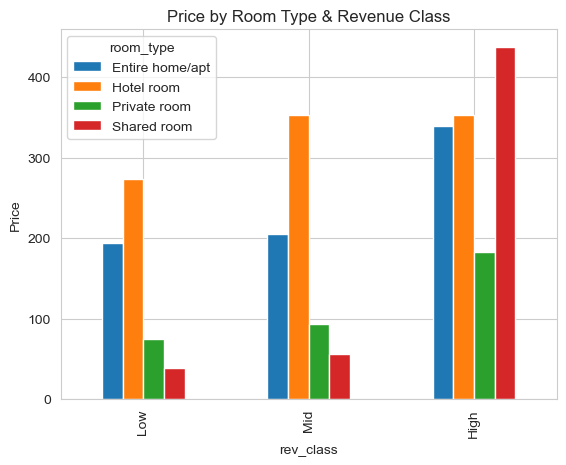

In [27]:
price_by_room_rev_class.plot(kind='bar')
plt.title("Price by Room Type & Revenue Class")
plt.ylabel("Price")
plt.show()

### Revenue Heatmap by Accommodation and Revenue Class

In [28]:
pivot = pd.pivot_table(
df,
values='estimated_revenue_l365d',
index='accommodates',
columns='rev_class',
aggfunc='mean')

/var/folders/f5/r_4n8c2j2qs88z3chgyzp6h00000gn/T/ipykernel_50813/689734451.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = pd.pivot_table(


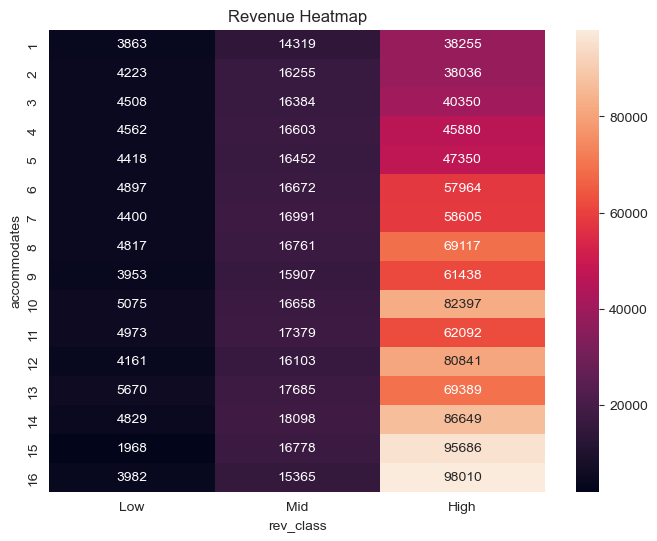

In [29]:
plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt=".0f")
plt.title("Revenue Heatmap")
plt.show()

### Which combination of room type and capacity performs the best?

In [30]:
segments = (
    df.groupby(['room_type', 'accommodates'])['estimated_revenue_l365d'].mean().sort_values(ascending=False).head(10)
)

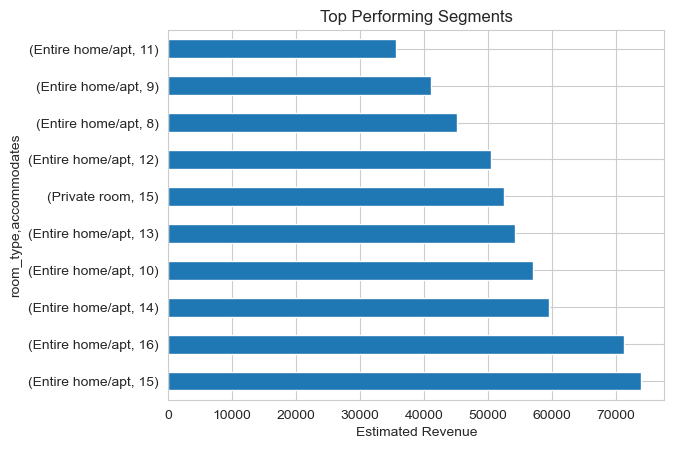

In [31]:
segments.plot(kind='barh')
plt.title("Top Performing Segments")
plt.xlabel("Estimated Revenue")
plt.show()

### Which combination of room type and capacity performs the worst?

In [32]:
segments = (df.groupby(['room_type', 'accommodates'])['estimated_revenue_l365d'].mean().sort_values(ascending=True).head(10))

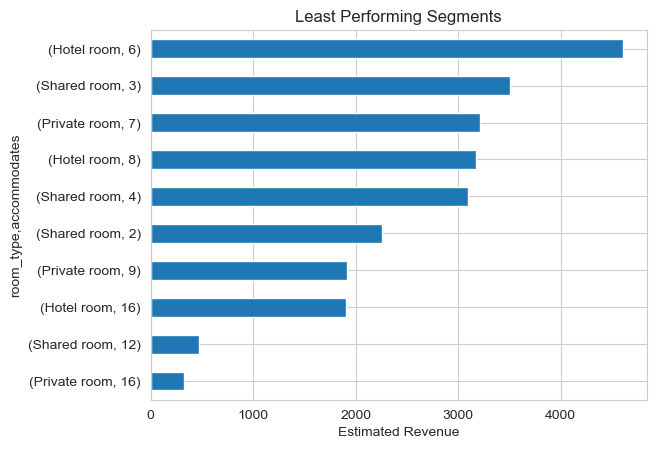

In [33]:
segments.plot(kind='barh')
plt.title("Least Performing Segments")
plt.xlabel("Estimated Revenue")
plt.show()

### What makes the top 5 highest revenue listings different from others?

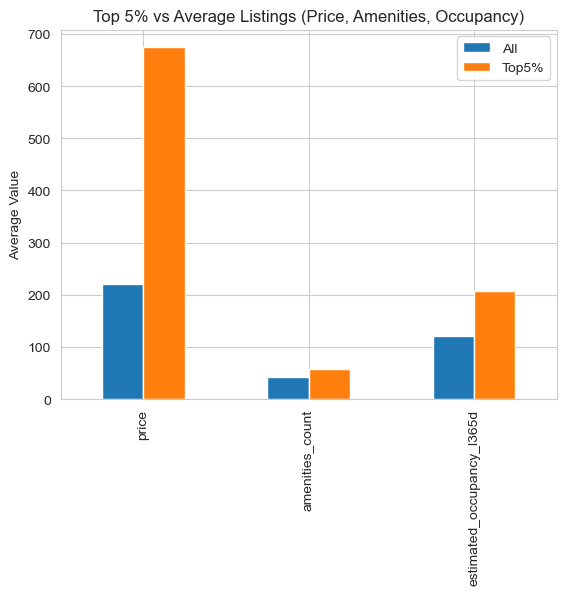

In [34]:
top5 = df[df['estimated_revenue_l365d'] > df['estimated_revenue_l365d'].quantile(0.95)]

comparison = pd.DataFrame({
"All": df.mean(numeric_only=True),
"Top5%": top5.mean(numeric_only=True)
})

comparison.loc[['price','amenities_count','estimated_occupancy_l365d']].plot(kind='bar')

plt.title("Top 5% vs Average Listings (Price, Amenities, Occupancy)")
plt.ylabel("Average Value")
plt.show()